In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/abdullah0a/student-dropout-analysis-and-prediction-dataset/student dropout.csv


In [7]:
df=pd.read_csv("/kaggle/input/datasets/abdullah0a/student-dropout-analysis-and-prediction-dataset/student dropout.csv")

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   School                       649 non-null    object
 1   Gender                       649 non-null    object
 2   Age                          649 non-null    int64 
 3   Address                      649 non-null    object
 4   Family_Size                  649 non-null    object
 5   Parental_Status              649 non-null    object
 6   Mother_Education             649 non-null    int64 
 7   Father_Education             649 non-null    int64 
 8   Mother_Job                   649 non-null    object
 9   Father_Job                   649 non-null    object
 10  Reason_for_Choosing_School   649 non-null    object
 11  Guardian                     649 non-null    object
 12  Travel_Time                  649 non-null    int64 
 13  Study_Time                   649 no

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df.head()

,School,Gender,Age,Address,Family_Size,Parental_Status,Mother_Education,Father_Education,Mother_Job,Father_Job,...,Free_Time,Going_Out,Weekend_Alcohol_Consumption,Weekday_Alcohol_Consumption,Health_Status,Number_of_Absences,Grade_1,Grade_2,Final_Grade,Dropped_Out
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,4,0,11,11,False
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,2,9,11,11,False
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,6,12,13,12,False
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,0,14,14,14,False
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,0,11,13,13,False


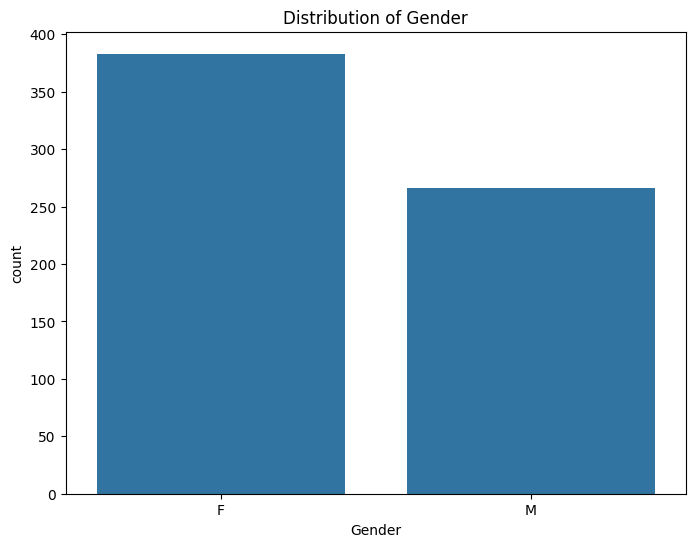

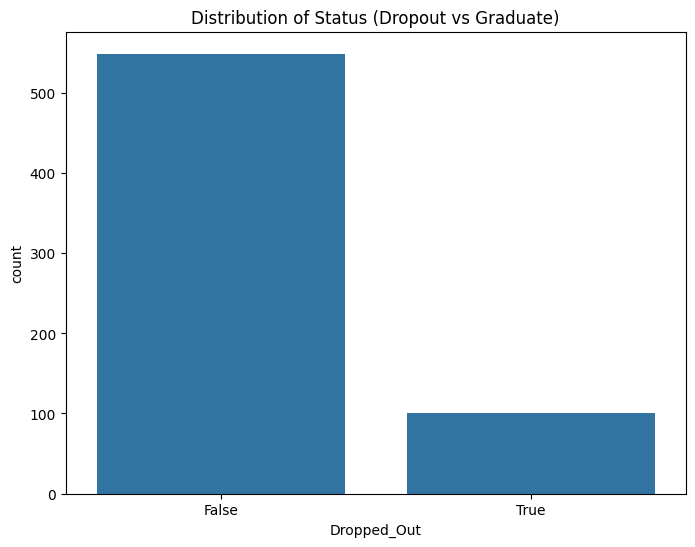

In [26]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Gender', data=df)
plt.title('Distribution of Gender')
plt.show()


plt.figure(figsize=(8, 6))
sns.countplot(x='Dropped_Out', data=df)
plt.title('Distribution of Status (Dropout vs Graduate)')
plt.show()

In [10]:
df["Dropped_Out"].value_counts()

Dropped_Out
False    549
True     100
Name: count, dtype: int64

In [11]:
for col in df.columns:
    print(df[col].value_counts())

School
GP    423
MS    226
Name: count, dtype: int64
Gender
F    383
M    266
Name: count, dtype: int64
Age
17    179
16    177
18    140
15    112
19     32
20      6
21      2
22      1
Name: count, dtype: int64
Address
U    452
R    197
Name: count, dtype: int64
Family_Size
GT3    457
LE3    192
Name: count, dtype: int64
Parental_Status
T    569
A     80
Name: count, dtype: int64
Mother_Education
2    186
4    175
1    143
3    139
0      6
Name: count, dtype: int64
Father_Education
2    209
1    174
3    131
4    128
0      7
Name: count, dtype: int64
Mother_Job
other       258
services    136
at_home     135
teacher      72
health       48
Name: count, dtype: int64
Father_Job
other       367
services    181
at_home      42
teacher      36
health       23
Name: count, dtype: int64
Reason_for_Choosing_School
course        285
home          149
reputation    143
other          72
Name: count, dtype: int64
Guardian
mother    455
father    153
other      41
Name: count, dtype: int64
Tr

In [12]:
from sklearn.preprocessing import StandardScaler

def preprocess_student_data(df):
    df_new = df.copy()

    #  Binary Encoding (Yes/No and 2-category strings)
    binary_map = {'yes': 1, 'no': 0, 'U': 1, 'R': 0, 'LE3': 0, 'GT3': 1, 'T': 0, 'A': 1, 'M': 1, 'F': 0, 'GP': 1, 'MS': 0}
    
    # List of all binary columns in dataset
    bin_cols = [
        'School', 'Gender', 'Address', 'Family_Size', 'Parental_Status', 
        'School_Support', 'Family_Support', 'Extra_Paid_Class', 
        'Extra_Curricular_Activities', 'Attended_Nursery', 
        'Wants_Higher_Education', 'Internet_Access', 'In_Relationship'
    ]
    
    for col in bin_cols:
        df_new[col] = df_new[col].map(binary_map)

    # 2. One-Hot Encoding (Nominal categories) 
    nominal_cols = ['Mother_Job', 'Father_Job', 'Reason_for_Choosing_School', 'Guardian']
    df_new = pd.get_dummies(df_new, columns=nominal_cols, drop_first=True)

    # 3. Target Variable 
    df_new['Dropped_Out'] = df_new['Dropped_Out'].astype(int)

    # 4. Feature Scaling (Numerical and Ordinal)
    # We scale everything that isn't a 0/1 dummy to keep the variance stable
    scale_cols = [
        'Age', 'Mother_Education', 'Father_Education', 'Travel_Time', 'Study_Time', 
        'Number_of_Failures', 'Family_Relationship', 'Free_Time', 'Going_Out', 
        'Weekend_Alcohol_Consumption', 'Weekday_Alcohol_Consumption', 
        'Health_Status', 'Number_of_Absences', 'Grade_1', 'Grade_2', 'Final_Grade'
    ]
    
    scaler = StandardScaler()
    df_new[scale_cols] = scaler.fit_transform(df_new[scale_cols])

    return df_new

# Processed data
# df_ready = preprocess_student_data(df)

In [13]:
df_ready=preprocess_student_data(df)

In [14]:
df_ready.head()

,School,Gender,Age,Address,Family_Size,Parental_Status,Mother_Education,Father_Education,Travel_Time,Study_Time,...,Mother_Job_teacher,Father_Job_health,Father_Job_other,Father_Job_services,Father_Job_teacher,Reason_for_Choosing_School_home,Reason_for_Choosing_School_other,Reason_for_Choosing_School_reputation,Guardian_mother,Guardian_other
0,1,0,1.031695,1,1,1,1.310216,1.540715,0.576718,0.083653,...,False,False,False,False,True,False,False,False,True,False
1,1,0,0.210137,1,1,0,-1.336039,-1.188832,-0.760032,0.083653,...,False,False,True,False,False,False,False,False,False,False
2,1,0,-1.432980,1,0,0,-1.336039,-1.188832,-0.760032,0.083653,...,False,False,True,False,False,False,True,False,True,False
3,1,0,-1.432980,1,1,0,1.310216,-0.278983,-0.760032,1.290114,...,False,False,False,True,False,True,False,False,True,False
4,1,0,-0.611422,1,1,0,0.428131,0.630866,-0.760032,0.083653,...,False,False,True,False,False,True,False,False,False,False


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

X = df_ready.drop(['Dropped_Out', 'Final_Grade'], axis=1)
y = df_ready['Dropped_Out']

#Train-test-split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [16]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train, y_train)
log_preds = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_preds))

Logistic Regression Accuracy: 0.9333333333333333


In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))

Random Forest Accuracy: 0.9384615384615385


In [18]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)
svm_preds = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_preds))

SVM Accuracy: 0.9230769230769231


In [20]:
from xgboost import XGBClassifier


xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)
print(f"XGBoost Accuracy: {accuracy_score(y_test, xgb_preds)}")

XGBoost Accuracy: 0.9333333333333333


Random Forest Evaluation for Dropout Prediction
Accuracy: 93.8%


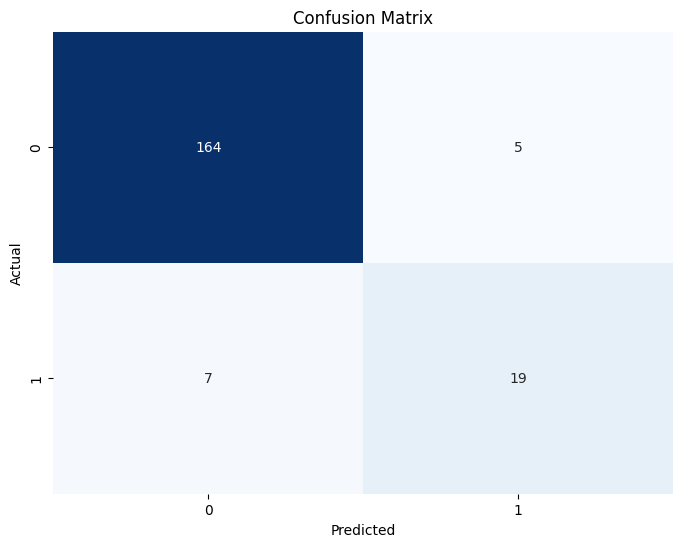

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.96       169
           1       0.79      0.73      0.76        26

    accuracy                           0.94       195
   macro avg       0.88      0.85      0.86       195
weighted avg       0.94      0.94      0.94       195



In [27]:
from sklearn.metrics import confusion_matrix 
# Evaluate the model
print("Random Forest Evaluation for Dropout Prediction")

# Display accuracy as a percentage with 1 decimal place
accuracy = accuracy_score(y_test, rf_preds) * 100
print(f"Accuracy: {accuracy:.1f}%")

# confusion matrix
cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Displaying the classification report
print("Classification Report:\n", classification_report(y_test, rf_preds))

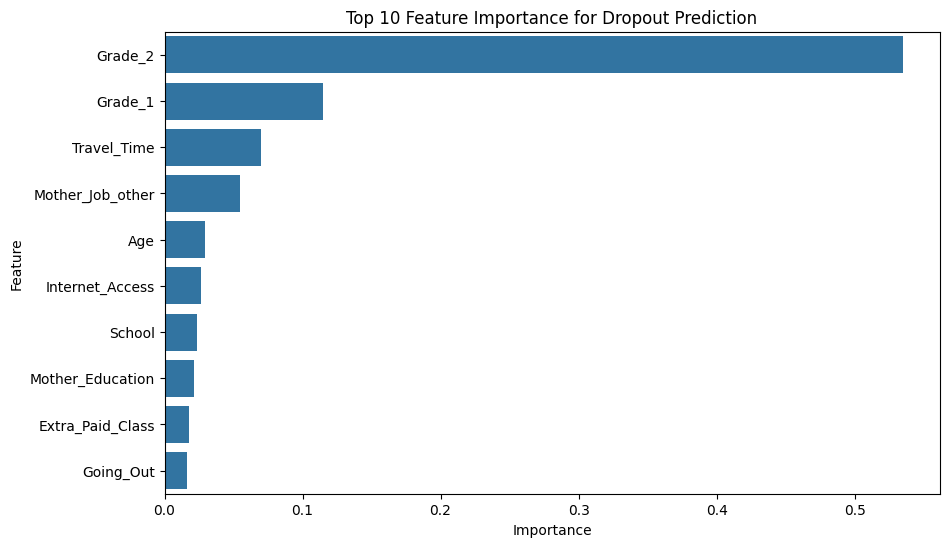

In [29]:
# Get feature importance from the model (for the 'Dropout' class)
feature_importances = rf_model.estimators_[0].feature_importances_

# Create a DataFrame for visualization
features = X_train.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})

# Sort the DataFrame by importance and select the top 10 features
top_10_importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)

# Visualize the top 10 feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_10_importance_df)
plt.title('Top 10 Feature Importance for Dropout Prediction')
plt.show()

In [30]:
import joblib


joblib.dump(rf_model, 'student_dropout_model.pkl')



['student_dropout_model.pkl']